# Multiclass_Classification

In [25]:
!pip install --upgrade pip
!pip install -q torch torchvision torchaudio pandas matplotlib scikit-learn seaborn pillow torchsummary

In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import datasets, models

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Dataset Setup
# Using Severstal Defect Dataset

This notebook uses the `Severstal: Steel Defect Detection` dataset, modified and containing 200 images each of 4 defect types:
- **Scratches**: Surface scratches and abrasions
- **Inclusions**: Foreign particles embedded in steel
- **Patches**: Localized surface irregularities  
- **Rolls Marks**: Marks from the rolling process

Directory structure:
```
single_class_sampled/
├── Scratches/      
├── Inclusions/     
├── Patches/         
└── Rolls Marks/    
```

In [ ]:
# Define path to dataset
dataset_path = r"PATH_TO_DATASET\single_class_sampled"

if not os.path.exists(dataset_path):
    print(f"Error: {dataset_path} folder not found!")
else:
    print(f"Dataset path: {os.path.abspath(dataset_path)}")

Dataset path: C:\Users\marsa964\MS-Workshop\single_class_sampled


In [3]:
# Get sorted class names
class_names = sorted(os.listdir(dataset_path))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Count images per class
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{class_name}: {num_images} images")

Classes found: ['Inclusions', 'Patches', 'Rolls Marks', 'Scratches']
Number of classes: 4
Inclusions: 195 images
Patches: 500 images
Rolls Marks: 500 images
Scratches: 500 images


In [4]:
# Load full dataset
BATCH_SIZE = 32
IMAGE_SIZE = 255

# PyTorch transforms (normalize with ImageNet stats for transfer learning)
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=dataset_path,
                                    transform=base_transform)

# Extract all images and labels as arrays for splitting
all_indices = list(range(len(full_dataset)))
all_labels  = [full_dataset.targets[i] for i in all_indices]

# First split: 70% train, 30% holdout (val + test)
train_idx, holdout_idx = train_test_split(
    all_indices, test_size=0.3, random_state=0, stratify=all_labels
)

holdout_labels = [all_labels[i] for i in holdout_idx]

# Second split: 15% val, 15% test
val_idx, test_idx = train_test_split(
    holdout_idx, test_size=0.5, random_state=0, stratify=holdout_labels
)

# Subset samplers
from torch.utils.data import Subset
train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Total images:       {len(full_dataset)}")
print(f"Training samples:   {len(train_dataset)} ({len(train_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Validation samples: {len(val_dataset)}   ({len(val_dataset)/len(full_dataset)*100:.1f}%)")
print(f"Test samples:       {len(test_dataset)}   ({len(test_dataset)/len(full_dataset)*100:.1f}%)")


Total images:       1695
Training samples:   1186 (70.0%)
Validation samples: 254   (15.0%)
Test samples:       255   (15.0%)


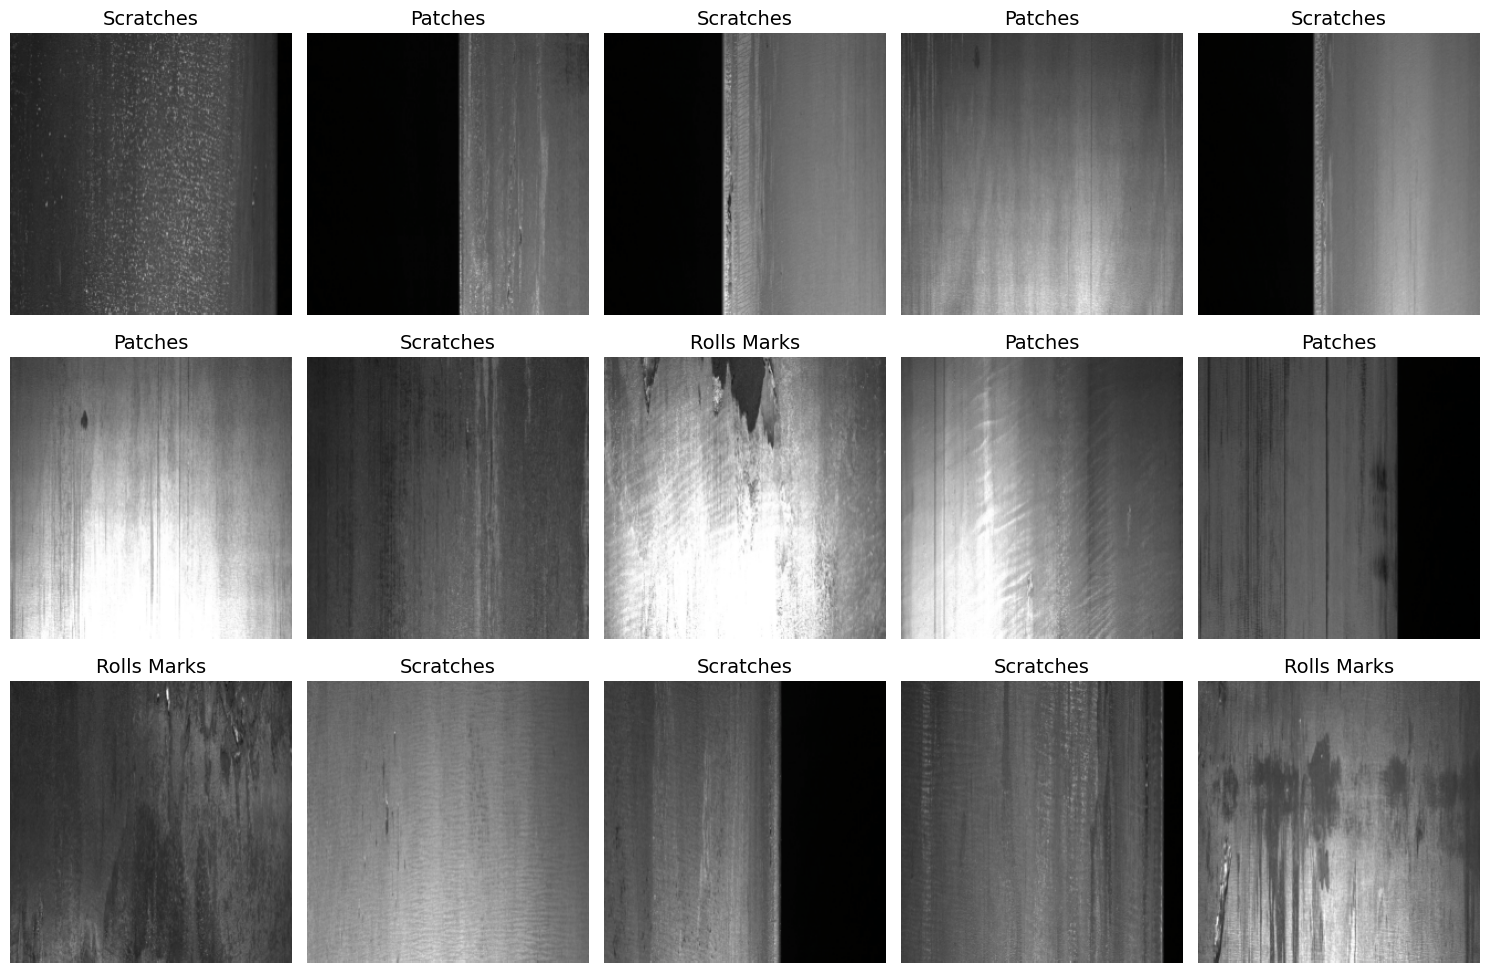

In [5]:
# Visualize sample images from training set
# (un-normalize for display)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

plt.figure(figsize=(15, 10))
images_batch, labels_batch = next(iter(train_loader))
for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels_batch[i].item()], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()


# Data Augmentation

In [16]:
augment_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.25, contrast=0.25),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.10)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

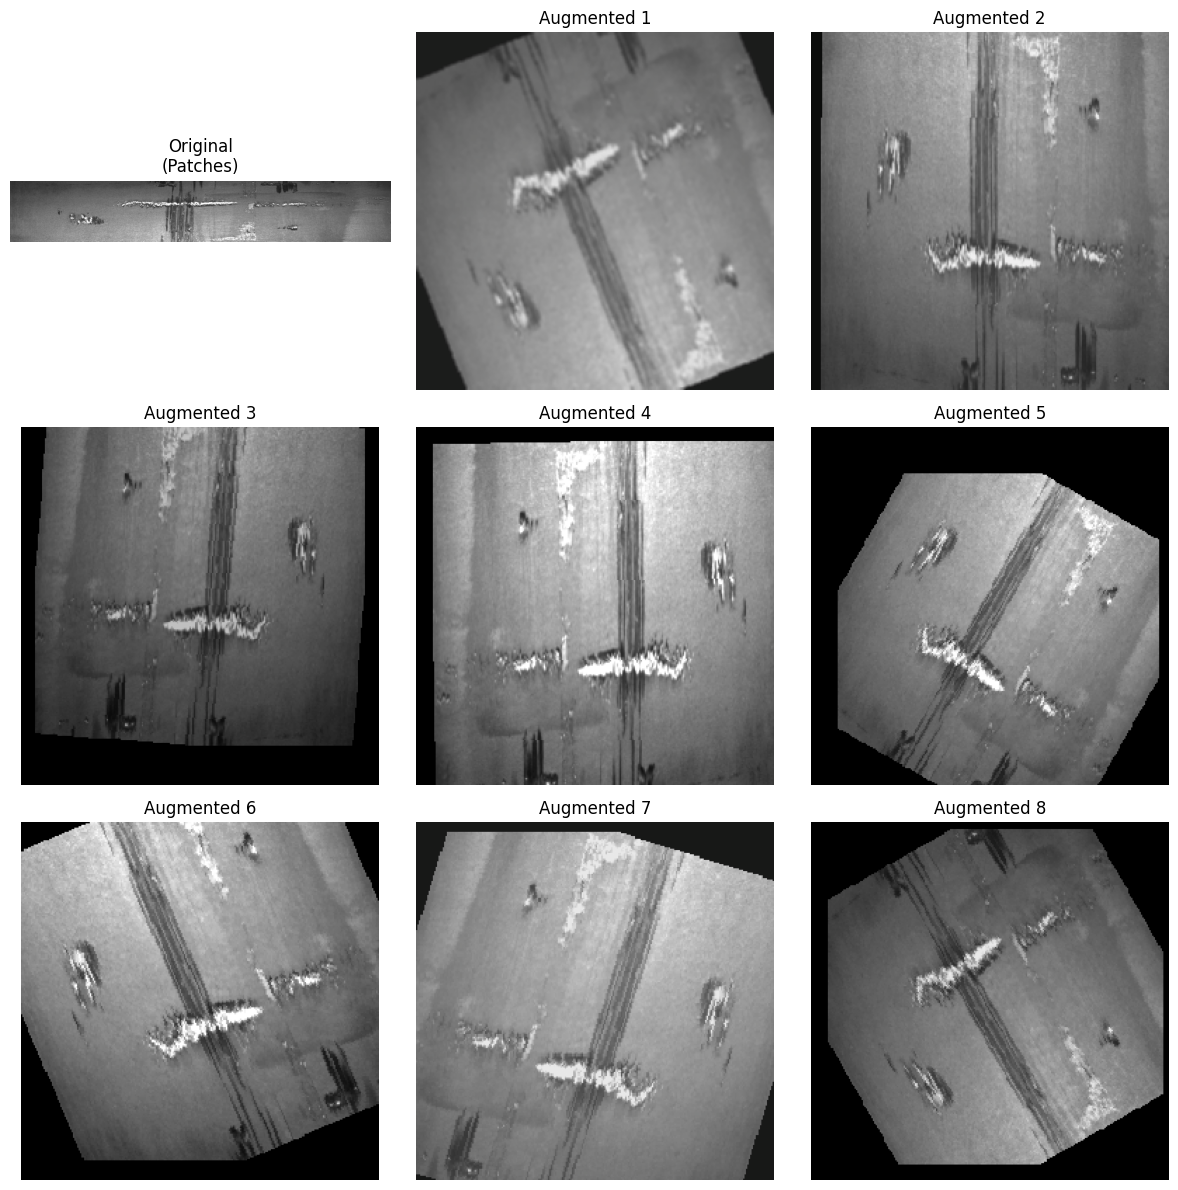

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

sample_dataset_index = train_dataset.indices[0]
sample_path, sample_label = full_dataset.samples[sample_dataset_index]
pil_img = Image.open(sample_path).convert("RGB")



inv_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

images = [pil_img] + [augment_transform(pil_img) for _ in range(8)]
titles = [f"Original\n({class_names[sample_label]})"] + [f"Augmented {i}" for i in range(1, 9)]

for ax, image, title in zip(axes, images, titles):
    if isinstance(image, torch.Tensor):
        image = inv_normalize(image).permute(1, 2, 0).numpy()
        image = np.clip(image, 0, 1)
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
# --- Apply augmentation to the training dataset -----
from torch.utils.data import Subset, ConcatDataset

def augment_dataset(dataset, multiplier):
    # Recover the original ImageFolder root and this subset's indices
    root = dataset.dataset.root
    indices = dataset.indices

    # Augmented "view" of the same folder, same samples, new transform
    augmented_base = datasets.ImageFolder(root=root, transform=augment_transform)
    augmented_subset = Subset(augmented_base, indices)

    return ConcatDataset([augmented_subset] * multiplier)


# Reassign the training loader (val/test loaders unchanged)
AUG_MULTIPLIER = 4
train_dataset2 = augment_dataset(train_dataset, multiplier=AUG_MULTIPLIER)
train_loader = DataLoader(train_dataset2, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Training samples: {len(train_dataset2)} ({AUG_MULTIPLIER}x, on-the-fly augmentation)")
print(f"Validation samples: {len(val_dataset)}  ")
print(f"Test samples:       {len(test_dataset)} ")


Training samples: 4744 (4x, on-the-fly augmentation)
Validation samples: 254  
Test samples:       255 


# Assignment: Comparison of the Original and Customized LeNet Models

In this lesson, you have learned about the original LeNet-5 architecture. Your task is to:

1- Train the original LeNet-5 model on the given dataset. Evaluate the model and report its performance (e.g., training loss, validation loss, accuracy, and test accuracy).

2- Modify the original model to create a customized LeNet model by replacing:

**Lazy layers (nn.LazyConv2d, nn.LazyLinear) with standard layers (nn.Conv2d, nn.Linear)

**Average Pooling with Max Pooling

**Sigmoid activations with ReLU

**Xavier initialization with PyTorch’s default  weight initialization

3-Compare the performance of the two models.

In your discussion, answer the following questions:

-How do the two architectures differ (e.g., activation functions, pooling layers, weight initialization, use of lazy layers)?

-Which model achieved better performance?

In [ ]:
def init_cnn(module):
    """Xavier initialization for Conv2d and Linear layers."""
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

class LeNetOriginal(nn.Module):
    def __init__(self, num_classes=4):
        super(LeNetOriginal, self).__init__()

        self.conv1 = nn.LazyConv2d(6, kernel_size=5, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.LazyConv2d(16, kernel_size=5, padding=0)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.LazyLinear(120)
        self.fc2 = nn.LazyLinear(84)
        self.fc3 = nn.LazyLinear(num_classes)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.conv1(x))
        x = self.pool1(x)

        x = self.sigmoid(self.conv2(x))
        x = self.pool2(x)

        x = x.flatten(1)

        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.fc3(x)

        return x

model_original = LeNetOriginal(num_classes=len(class_names)).to(device)
print(f"Input shape: [{BATCH_SIZE}, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]")
summary(model_original, input_size=(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE))

Input shape: [32, 3, 255, 255]


Layer (type:depth-idx)                   Output Shape              Param #
LeNetOriginal                            [32, 4]                   --
├─Conv2d: 1-1                            [32, 6, 255, 255]         456
├─Sigmoid: 1-2                           [32, 6, 255, 255]         --
├─AvgPool2d: 1-3                         [32, 6, 127, 127]         --
├─Conv2d: 1-4                            [32, 16, 123, 123]        2,416
├─Sigmoid: 1-5                           [32, 16, 123, 123]        --
├─AvgPool2d: 1-6                         [32, 16, 61, 61]          --
├─Linear: 1-7                            [32, 120]                 7,144,440
├─Sigmoid: 1-8                           [32, 120]                 --
├─Linear: 1-9                            [32, 84]                  10,164
├─Sigmoid: 1-10                          [32, 84]                  --
├─Linear: 1-11                           [32, 4]                   340
Total params: 7,157,816
Trainable params: 7,157,816
Non-trainable par

# Solution for customized LeNet architecture

In [ ]:
# Define LeNet model in PyTorch
from torchsummary import summary

class LeNet(nn.Module):
    def __init__(self, num_classes=4):
        super(LeNet, self).__init__()
        
        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Second convolutional layer
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(16 * 60 * 60, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

# Create model
model_lenet = LeNet(num_classes=len(class_names)).to(device)
print(f"Input shape: [{BATCH_SIZE}, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]")
summary(model_lenet, input_size=(3, IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE)

Input shape: [32, 3, 255, 255]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [32, 6, 251, 251]             456
              ReLU-2          [32, 6, 251, 251]               0
         MaxPool2d-3          [32, 6, 125, 125]               0
            Conv2d-4         [32, 16, 121, 121]           2,416
              ReLU-5         [32, 16, 121, 121]               0
         MaxPool2d-6           [32, 16, 60, 60]               0
            Linear-7                  [32, 120]       6,912,120
              ReLU-8                  [32, 120]               0
            Linear-9                   [32, 84]          10,164
             ReLU-10                   [32, 84]               0
           Linear-11                    [32, 4]             340
Total params: 6,925,496
Trainable params: 6,925,496
Non-trainable params: 0
------------------------------------------------------------

In [43]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [47]:
# Training parameters
EPOCHS = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lenet.parameters(), lr=0.001)

# Training loop
history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_lenet, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model_lenet, val_loader, criterion, device)
    
    history['loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/5 - Loss: 0.8178, Acc: 0.6543, Val Loss: 0.7325, Val Acc: 0.6811
Epoch 2/5 - Loss: 0.7816, Acc: 0.6800, Val Loss: 0.6870, Val Acc: 0.7283
Epoch 3/5 - Loss: 0.7415, Acc: 0.6920, Val Loss: 0.6609, Val Acc: 0.7441
Epoch 4/5 - Loss: 0.7349, Acc: 0.6971, Val Loss: 0.7232, Val Acc: 0.6890
Epoch 5/5 - Loss: 0.6968, Acc: 0.7148, Val Loss: 0.6111, Val Acc: 0.7598


In [51]:
# Save the model
torch.save(model_lenet.state_dict(), 'lenet_model.pth')
print("Model saved as lenet_model.pth")

Model saved as lenet_model.pth


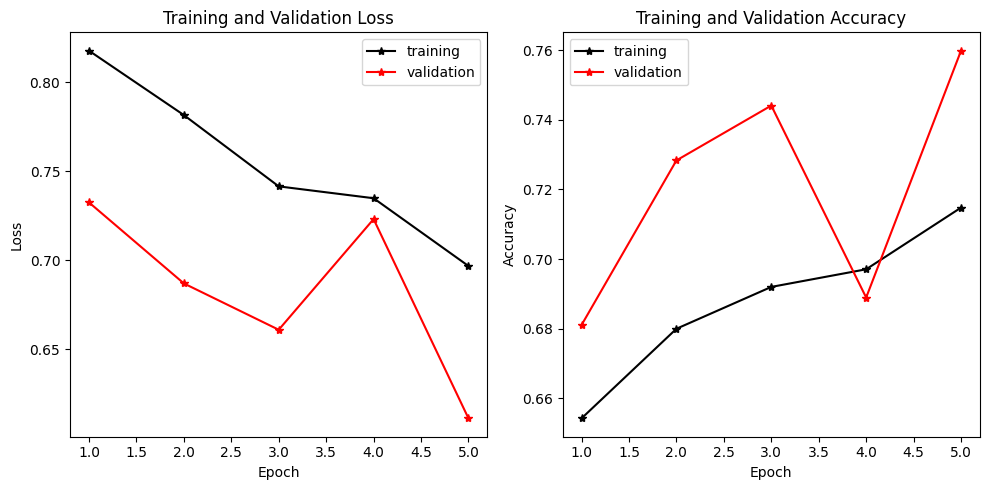

In [48]:
# Plot training history - Loss and Accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(np.arange(1, EPOCHS+1), history['loss'], color='black', label='training', marker='*')
plt.plot(np.arange(1, EPOCHS+1), history['val_loss'], color='red', label='validation', marker='*')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(np.arange(1, EPOCHS+1), history['accuracy'], color='black', label='training', marker='*')
plt.plot(np.arange(1, EPOCHS+1), history['val_accuracy'], color='red', label='validation', marker='*')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.tight_layout()
plt.show()

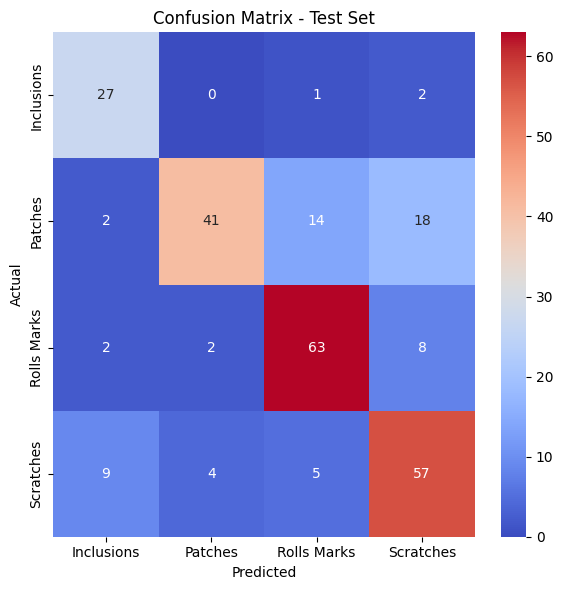


Classification Report - Test Set:
              precision    recall  f1-score   support

  Inclusions       0.68      0.90      0.77        30
     Patches       0.87      0.55      0.67        75
 Rolls Marks       0.76      0.84      0.80        75
   Scratches       0.67      0.76      0.71        75

    accuracy                           0.74       255
   macro avg       0.74      0.76      0.74       255
weighted avg       0.76      0.74      0.73       255



In [49]:
# Compute confusion matrix and classification report on test data
model_lenet.eval()
ypred_tot = []
label_tot = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_lenet(images)
        _, predicted = torch.max(outputs, 1)
        ypred_tot.extend(predicted.cpu().numpy())
        label_tot.extend(labels.numpy())

# Create confusion matrix
cm = confusion_matrix(label_tot, ypred_tot)

# Display confusion matrix as heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, cmap="coolwarm", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report - Test Set:")
print(classification_report(label_tot, ypred_tot, labels=range(len(class_names)), target_names=class_names))

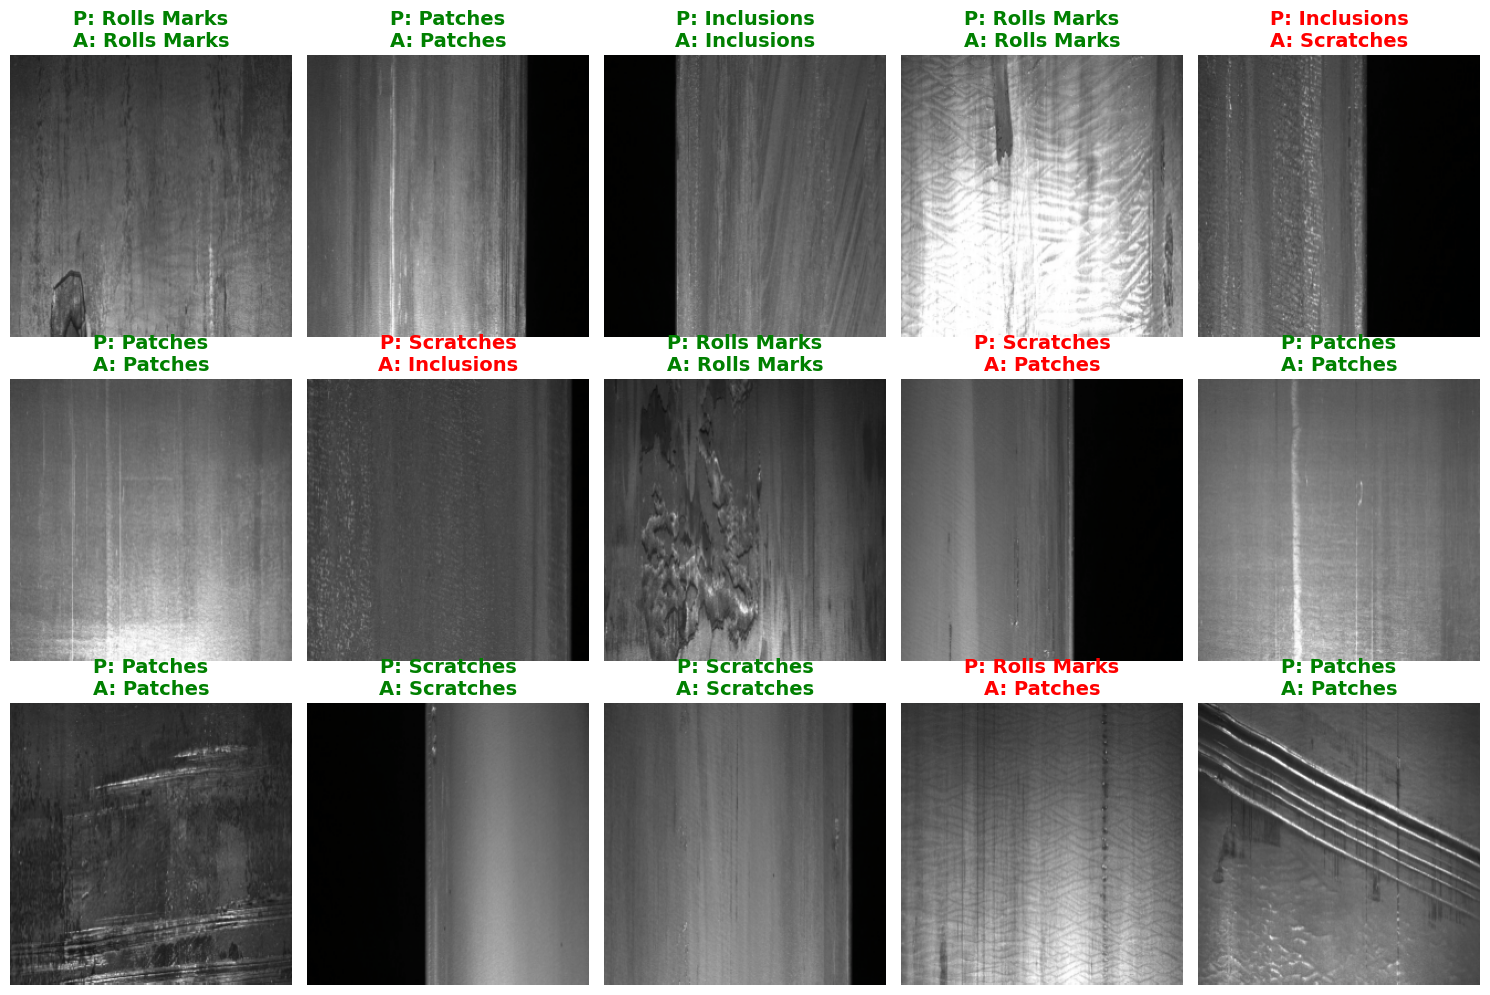


EVALUATING ON TEST SET
Test Loss: 0.7035
Test Accuracy: 0.7373 (73.73%)


In [51]:
# Visualize predictions on test set
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

plt.figure(figsize=(15, 10))
model_lenet.eval()

with torch.no_grad():
    images_batch, labels_batch = next(iter(test_loader))
    outputs = model_lenet(images_batch.to(device))
    _, ypred = torch.max(outputs, 1)

    for i in range(min(15, len(images_batch))):
        ax = plt.subplot(3, 5, i + 1)
        img = inv_normalize(images_batch[i]).permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        plt.imshow(img)

        actual_class = labels_batch[i].item()
        pred_class = ypred[i].item()
        color = 'green' if actual_class == pred_class else 'red'
        plt.title(
            f"P: {class_names[pred_class]}\nA: {class_names[actual_class]}",
            color=color,
            fontweight='bold',
            fontsize=14
        )
        plt.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EVALUATING ON TEST SET")
test_loss, test_acc = validate(model_lenet, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Assignment: Apply the AlexNet model
Your task is apply AlexNet model to the dataset and then repeat the experiment by modifying number of filters (c1- c5), and fully connected layers (fc1, fc2), as well as dropout rates. 
Analyze and explain how these changes affect model performance and discuss how they can be used to customize and improve the model for the specific dataset.

In [52]:
import torch
import torch.nn as nn

class CustomAlexNetBN(nn.Module):
    def __init__(
        self,
        num_classes=4,
        c1=96,
        c2=256,
        c3=384,
        c4=384,
        c5=256,
        fc1=1024,
        fc2=512,
        dropout=0.5
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, c1, kernel_size=11, stride=4, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(c1, c2, kernel_size=5, padding=2),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),

            nn.Conv2d(c3, c4, kernel_size=3, padding=1),
            nn.BatchNorm2d(c4),
            nn.ReLU(inplace=True),

            nn.Conv2d(c4, c5, kernel_size=3, padding=1),
            nn.BatchNorm2d(c5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((6, 6)),
            nn.Flatten(),

            nn.Linear(c5 * 6 * 6, fc1),
            nn.BatchNorm1d(fc1),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc1, fc2),
            nn.BatchNorm1d(fc2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(fc2, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_custom = CustomAlexNetBN(num_classes=len(class_names)).to(device)
print(f"Input shape: [{BATCH_SIZE}, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]")
summary(model_custom, input_size=(3, IMAGE_SIZE, IMAGE_SIZE))

Input shape: [32, 3, 255, 255]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 62, 62]          34,944
       BatchNorm2d-2           [-1, 96, 62, 62]             192
              ReLU-3           [-1, 96, 62, 62]               0
         MaxPool2d-4           [-1, 96, 30, 30]               0
            Conv2d-5          [-1, 256, 30, 30]         614,656
       BatchNorm2d-6          [-1, 256, 30, 30]             512
              ReLU-7          [-1, 256, 30, 30]               0
         MaxPool2d-8          [-1, 256, 14, 14]               0
            Conv2d-9          [-1, 384, 14, 14]         885,120
      BatchNorm2d-10          [-1, 384, 14, 14]             768
             ReLU-11          [-1, 384, 14, 14]               0
           Conv2d-12          [-1, 384, 14, 14]       1,327,488
      BatchNorm2d-13          [-1, 384, 14, 14]             768
        

In [53]:
# Training parameters for custom model
EPOCHS = 6
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_custom.parameters(), lr=0.001)

# Training loop
history_custom = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': []
}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model_custom, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model_custom, val_loader, criterion, device)
    
    history_custom['loss'].append(train_loss)
    history_custom['val_loss'].append(val_loss)
    history_custom['accuracy'].append(train_acc)
    history_custom['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/6 - Loss: 1.1716, Acc: 0.4490, Val Loss: 0.8726, Val Acc: 0.6378
Epoch 2/6 - Loss: 1.0211, Acc: 0.5369, Val Loss: 0.8665, Val Acc: 0.6181
Epoch 3/6 - Loss: 0.9728, Acc: 0.5578, Val Loss: 0.8221, Val Acc: 0.6378
Epoch 4/6 - Loss: 0.9393, Acc: 0.5936, Val Loss: 0.7801, Val Acc: 0.6732
Epoch 5/6 - Loss: 0.9098, Acc: 0.6187, Val Loss: 0.7141, Val Acc: 0.6929
Epoch 6/6 - Loss: 0.8728, Acc: 0.6324, Val Loss: 0.7158, Val Acc: 0.7244


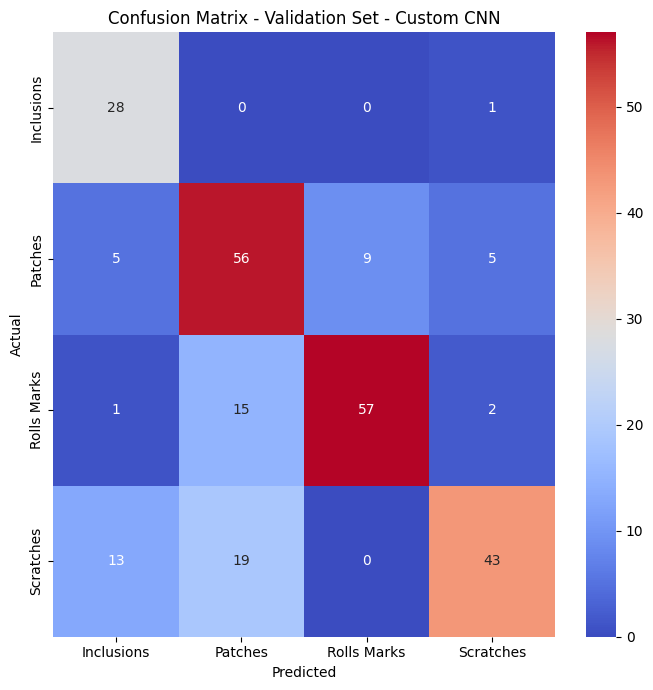


Classification Report - Custom CNN:
              precision    recall  f1-score   support

  Inclusions       0.60      0.97      0.74        29
     Patches       0.62      0.75      0.68        75
 Rolls Marks       0.86      0.76      0.81        75
   Scratches       0.84      0.57      0.68        75

    accuracy                           0.72       254
   macro avg       0.73      0.76      0.73       254
weighted avg       0.76      0.72      0.72       254



In [54]:
# Compute confusion matrix and classification report on validation data for custom model
model_custom.eval()
ypred_tot = []
label_tot = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_custom(images)
        _, predicted = torch.max(outputs, 1)
        ypred_tot.extend(predicted.cpu().numpy())
        label_tot.extend(labels.numpy())

# Create confusion matrix
cm = confusion_matrix(label_tot, ypred_tot)

# Display confusion matrix as heatmap
plt.figure(figsize=(7, 7))
sns.heatmap(cm, annot=True, cmap="coolwarm", xticklabels=class_names, yticklabels=class_names, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Validation Set - Custom CNN')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report - Custom CNN:")
print(classification_report(label_tot, ypred_tot, labels=range(len(class_names)), target_names=class_names))